In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import cvxpy as cp
import os
from google.colab import drive
import warnings

# Tắt tất cả các warning liên quan đến user (bao gồm cái của cvxpy)
warnings.filterwarnings("ignore", category=UserWarning)

# HOẶC: Chỉ tắt đúng cái warning về ma trận này (An toàn hơn)
warnings.filterwarnings("ignore", message=".*matrix multiplication.*")

# ==========================================
# 1. MOUNT GOOGLE DRIVE
# ==========================================
# Bước này sẽ yêu cầu bạn cấp quyền truy cập Drive
drive.mount('/content/drive', force_remount=True)

MessageError: Error: credential propagation was unsuccessful

In [21]:
# --- CES / Linear (m = CES exponent, m=1 → Linear, m='inf' → Leontief-like max) ---
def calculate_ces_utility(allocation_vec, valuation_vec, m_ces = 1/2):
    eps = 1e-9
    return np.power(np.power(allocation_vec + eps, m_ces).T @ valuation_vec, (1/m_ces))


# --- COBB–DOUGLAS UTILITY ---
def calculate_cd_utility(allocation_vec, valuations_vec):
    eps = 1e-12
    v = np.atleast_2d(valuations_vec)
    x = np.atleast_2d(allocation_vec)

    # Normalize weights α_j = v_j / sum(v)
    weights = v / (np.sum(v, axis=1, keepdims=True))

    # log utility = Σ α_j log(x_j)
    log_u = np.sum(weights * np.log(x + eps), axis=1)

    u = np.exp(log_u)

    return u


# --- LEONTIEF UTILITY ---
def calculate_leo_utility(allocation_vec, valuations_vec):
    v = np.atleast_2d(valuations_vec)
    x = np.atleast_2d(allocation_vec)
    # 1. Khởi tạo mảng kết quả là Vô cực (Infinity)
    # Để nếu v=0, giá trị tại đó vẫn là Inf và không bị hàm min chọn phải
    ratios = np.full_like(x, 1e30)

    # 2. Chỉ thực hiện phép chia ở những nơi v > 0
    # Ghi đè kết quả phép chia vào mảng ratios
    np.divide(x, v, out=ratios, where=(v > 1e-12))

    # 3. Lấy Min theo hàng (axis=1)
    u = np.min(ratios, axis=1)

    return u


## 1a

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import os
import time

# ==============================================================================
# 1. CORE FUNCTIONS
# ==============================================================================

def build_A_matrix(n_goods, n_slots):
    """Tạo ma trận ánh xạ Goods -> Slots"""
    A = np.zeros((n_slots, n_goods))
    for j in range(n_goods):
        A[j % n_slots, j] = 1.0
    return A

import numpy as np

def buyer_best_response_cvx(v_i, p, A, q_i, B_i, utility_type="Linear"):
    """
    Phiên bản siêu tốc của buyer_best_response.
    Sử dụng Closed-form solution cho mọi hàm utility.
    KHÔNG DÙNG CVXPY.
    """
    # 1. Tính giá hiệu dụng (Effective Price)
    # p: (M,), A.T @ q_i: (M,)
    effective_price = p + (A.T @ q_i)

    # An toàn: Đảm bảo giá > 0 để tránh chia cho 0
    safe_price = np.maximum(effective_price, 1e-9)

    m_goods = len(v_i)
    x = np.zeros(m_goods)

    # =========================================================
    # 1. LINEAR UTILITY: U = sum(v * x)
    # =========================================================
    if utility_type == "Linear":
        # Chiến thuật: Bang-per-buck (Mua tất tay món hời nhất)
        bang_per_buck = v_i / safe_price
        best_idx = np.argmax(bang_per_buck)
        x[best_idx] = B_i / safe_price[best_idx]

    # =========================================================
    # 2. COBB-DOUGLAS: U = prod(x^alpha) hoặc sum(alpha * log(x))
    # =========================================================
    elif utility_type == "Cobb-Douglas":
        # Chuẩn hóa alpha (Bắt buộc để thỏa mãn Budget constraint)
        sum_v = np.sum(v_i)
        if sum_v > 0:
            alpha = v_i / sum_v
        else:
            alpha = np.zeros_like(v_i) # Tránh lỗi nếu v toàn 0

        # Công thức: Chi tiêu đúng tỷ lệ alpha
        # x_i = (alpha_i * Budget) / Price_i
        x = (alpha * B_i) / safe_price

    # =========================================================
    # 3. LEONTIEF: U = min(x / v)
    # =========================================================
    elif utility_type == "Leontief":
        # Chiến thuật: Mua theo tỷ lệ cố định của v
        # Giá của 1 combo chuẩn = sum(v_i * p_i)
        cost_of_one_bundle = np.dot(v_i, safe_price)

        if cost_of_one_bundle > 0:
            # Số lượng combo mua được
            num_bundles = B_i / cost_of_one_bundle
            x = num_bundles * v_i
        else:
            x = np.zeros(m_goods)

    # =========================================================
    # 4. CES UTILITY: U = (sum v * x^rho)^(1/rho)
    # =========================================================
    elif utility_type == "CES_8":
        # CẤU HÌNH rho (m) TẠI ĐÂY
        # Trong code cũ bạn để m = 1/2
        rho = 0.5

        # --- CASE A: CONCAVE (rho < 1, rho != 0) ---
        # Đây là trường hợp thay thế (Substitute) -> Mua nhiều loại
        if rho < 1:
            # Tính Sigma (Elasticity of Substitution)
            # sigma = 1 / (1 - rho)
            sigma = 1.0 / (1.0 - rho)

            # Tính phần tử tỷ lệ: Term_i = (v_i / p_i)^sigma
            # Dùng np.maximum cho v_i để tránh v=0 gây lỗi log hoặc mũ âm
            term = np.power(v_i / safe_price, sigma)

            # Tính mẫu số chung: Sum (p_j * term_j)
            denom = np.dot(safe_price, term)

            if denom > 0:
                # x_i = (B * term_i) / denom
                x = (B_i * term) / denom
            else:
                 # Fallback nếu v=0 hết
                 x = np.zeros(m_goods)

        # --- CASE B: CONVEX (rho > 1) ---
        # Đây là trường hợp "Winner Takes All" giống Linear
        else:
            # So sánh tỷ lệ: v^(1/rho) / p
            v_transformed = np.power(v_i, 1.0/rho)
            bang_per_buck = v_transformed / safe_price

            best_idx = np.argmax(bang_per_buck)
            x[best_idx] = B_i / safe_price[best_idx]

    return x

def solve_centralized_optimal_fair(valuations, budgets, supply_s, b_mat, A, utility_type="Linear"):
    """
    Returns:
        optimal_value (float): Giá trị hàm mục tiêu tối ưu.
        optimal_X (np.ndarray): Ma trận phân bổ tối ưu (N x M).
    """
    n, m = valuations.shape
    X = cp.Variable((n, m), nonneg=True)

    constraints = [
        cp.sum(X, axis=0) <= supply_s
    ]
    for i in range(n):
        constraints.append(A @ X[i] <= b_mat[i])

    # --- XÂY DỰNG OBJECTIVE ---
    if utility_type == "Linear":
        utilities = cp.sum(cp.multiply(valuations, X), axis=1)
        primal_utility = cp.sum(cp.multiply(budgets, cp.log(utilities + 1e-12)))

    elif utility_type == "Cobb-Douglas":
        eps = 1e-12
        alpha = valuations / (np.sum(valuations, axis=1, keepdims=True))
        log_utilities = cp.sum(cp.multiply(alpha, cp.log(X + eps)), axis=1)
        primal_utility = cp.sum(cp.multiply(budgets, log_utilities))

    elif utility_type == "Leontief":
        # Lưu ý: Leontief trong CVXPY có thể phức tạp/chậm với quy mô lớn
        inv_valuations = np.divide(
            1.0,
            valuations,
            out=np.full_like(valuations, 1e30),
            where=(valuations > 0)
        )

        # 2. Nhân X với ma trận nghịch đảo hằng số này
        # ratio_matrix[i, j] = X[i, j] * (1 / v[i, j])
        weighted_X = cp.multiply(X, inv_valuations)

        # 3. Lấy min theo hàng
        utilities = cp.min(weighted_X, axis=1)

        # 4. Tính hàm mục tiêu
        primal_utility = cp.sum(cp.multiply(budgets, cp.log(utilities + 1e-12)))

    elif utility_type == "CES_8":
        # Nếu chạy Solver tập trung, m NÊN nhỏ hơn hoặc bằng 1 (ví dụ 0.5 hoặc -1).
        # Nếu đặt m = 8, Solver ECOS/SCS sẽ KHÔNG giải được (báo lỗi DCPError).
        eps = 1e-9
        m_ces = 1/2

        # Công thức: log_util = (1/m) * log( sum( v * x^m ) )
        # Tính tổng trọng số lũy thừa theo hàng (axis=1)
        inner_term = cp.sum(cp.multiply(valuations, cp.power(X + eps, m_ces)), axis=1)

        # Logarit hóa hàm mục tiêu
        log_utilities = (1.0 / m_ces) * cp.log(inner_term)

        primal_utility = cp.sum(cp.multiply(budgets, log_utilities))

    objective = cp.Maximize(primal_utility)
    prob = cp.Problem(objective, constraints)

    print(f"--- Solving Centralized Fair Problem ({utility_type}) ---")
    try:
        prob.solve(solver=cp.ECOS, verbose=False)
    except:
        prob.solve(solver=cp.SCS, verbose=False)

    # TRẢ VỀ: (Giá trị mục tiêu, Ma trận X tối ưu)
    return prob.value, X.value


def one_sample_sgd_fastlog(
    A: np.ndarray, b: np.ndarray, supply_s: np.ndarray, q0: np.ndarray,
    valuations: np.ndarray, budgets: np.ndarray, p0: np.ndarray,
    lr_p=0.01, lr_q=0.01, num_iters=1000, seed=42, log_freq=10,
    utility_type="Linear"
):
    rng = np.random.default_rng(seed)
    n, m = valuations.shape

    # Copy biến dual
    p = p0.copy()
    q = q0.copy()

    # --- BƯỚC 1: KHỞI TẠO TUYỆT ĐỐI (X0 = 100) ---
    X = np.ones((n, m)) * 1
    util = util = np.zeros(n)
    for j in range(n):
        if utility_type == "Linear":
            util[j] = valuations[j] @ X[j]
        elif utility_type == "Cobb-Douglas":
            util[j] = calculate_cd_utility(X[j], valuations[j])
        elif utility_type == "Leontief":
            util[j] = calculate_leo_utility(X[j], valuations[j])
        elif utility_type == "CES_8":
            util[j] = calculate_ces_utility(X[j], valuations[j], m_ces=0.5)

    # Khởi tạo lịch sử
    obj_hist = []
    real_allocation_hist = []

    # --- BƯỚC 2: LƯU TRẠNG THÁI T=0 (KHI X VẪN LÀ 0) ---
    # Tính Objective tại điểm xuất phát (lúc này chưa ai mua gì)
    term_p = np.sum(p * supply_s)
    term_q = np.sum(q * b)
    # Lưu ý: log(0 + 1e-12) sẽ ra số âm rất lớn (khoảng -27), đây là đúng toán học
    term_u = np.sum(budgets * np.log(util + 1e-12))
    obj_0 = term_p + term_q + term_u - np.sum(budgets)

    # LƯU NGAY LẬP TỨC
    obj_hist.append(obj_0)
    real_allocation_hist.append(X.copy()) # Lưu ma trận toàn số 0

    print(f"--- Start SGD ({num_iters} iterations) | Initial Obj (X=0): {obj_0:.2f} ---")
    t0 = time.perf_counter()

    # --- BƯỚC 3: WARM UP (LÀM NÓNG) ---
    # Bây giờ mới tính toán phân bổ lần đầu dựa trên giá p0, q0
    # Bước này cần thiết để có Tổng Cầu (D) khởi tạo cho vòng lặp SGD
    for j in range(n):
        # Dùng hàm Analytical siêu tốc
        X[j] = buyer_best_response_cvx(valuations[j], p, A, q[j], budgets[j], utility_type)

        # Cập nhật util để dùng cho vòng lặp sau
        if utility_type == "Linear":
            util[j] = valuations[j] @ X[j]
        elif utility_type == "Cobb-Douglas":
            util[j] = calculate_cd_utility(X[j], valuations[j])
        elif utility_type == "Leontief":
            util[j] = calculate_leo_utility(X[j], valuations[j])
        elif utility_type == "CES_8":
            util[j] = calculate_ces_utility(X[j], valuations[j], m_ces=0.5)

    # Tính Tổng cầu ban đầu (D) sau khi Warm up
    D = X.sum(axis=0)

    # --- BƯỚC 4: VÒNG LẶP SGD CHÍNH (TỪ T=1) ---
    for t in range(1, num_iters + 1):
        # A. Chọn ngẫu nhiên 1 user
        i = rng.integers(0, n)

        # B. Cập nhật Demand (Incremental)
        D -= X[i]

        # C. Tìm Best Response (Analytical)
        x_new = buyer_best_response_cvx(valuations[i], p, A, q[i], budgets[i], utility_type)

        # Cập nhật X và Utility
        X[i] = x_new

        if utility_type == "Linear":
            util[i] = valuations[i] @ X[i]
        elif utility_type == "Cobb-Douglas":
            util[i] = calculate_cd_utility(X[i], valuations[i])
        elif utility_type == "Leontief":
            util[i] = calculate_leo_utility(X[i], valuations[i])
        elif utility_type == "CES_8":
            util[i] = calculate_ces_utility(X[i], valuations[i], m_ces=0.5)

        D += x_new

        # D. Tính Gradient & Cập nhật Dual
        g_p = D - supply_s
        load_i = A @ x_new
        g_q_i = load_i - b[i]

        alpha = lr_p / np.sqrt(t)
        beta  = lr_q / np.sqrt(t)

        p = np.maximum(0, p + alpha * g_p)
        q[i] = np.maximum(0, q[i] + beta * g_q_i)

        # E. Ghi Log định kỳ
        if t % log_freq == 0:
            term_p = np.sum(p * supply_s)
            term_q = np.sum(q * b)
            term_u = np.sum(budgets * np.log(util + 1e-12))
            obj = term_p + term_q + term_u - np.sum(budgets)

            obj_hist.append(obj)
            real_allocation_hist.append(X.copy())

            if t % 5000 == 0:
                print(f"Iter {t}/{num_iters} | Obj: {obj:.4f}")

    total_time = time.perf_counter() - t0
    print(f"--- Finished in {total_time:.2f}s ---")

    return obj_hist, real_allocation_hist

# ==============================================================================
# 2. MAIN SCRIPT
# ==============================================================================

# --- A. LOAD VALUATIONS ---
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_10u_24i"
print(f"--- Loading Data ---")
try:
    val_path = os.path.join(FACTOR_DIR, "valuation_matrix.npy")
    if os.path.exists(val_path):
        valuations = np.load(val_path)
    else:
        U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
        P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
        valuations = U @ P.T
    print(f"✓ Valuations Shape: {valuations.shape}")
except:
    print("⚠️ Dùng dữ liệu ngẫu nhiên (Random Valuations)")
    valuations = np.random.rand(10, 24) + 0.1
valuations /= 10

N_USERS, M_GOODS = valuations.shape
T_SLOTS = 4

--- Loading Data ---
✓ Valuations Shape: (10, 24)


In [23]:
# ==============================================================================
# 3. PARAMETER
# ==============================================================================
np.random.seed(1)

# [1] Budgets
budgets = np.ones(N_USERS) * 10

# [2] Supply
supply_s = np.random.uniform(5, 10, M_GOODS)

# [3] Capacity (Ma trận N x T)
capacity_b = np.random.uniform(1, 4, (N_USERS, T_SLOTS))

# Matrix A
if M_GOODS % T_SLOTS == 0:
    A_matrix = build_A_matrix(M_GOODS, T_SLOTS)
else:
    A_matrix = np.zeros((T_SLOTS, M_GOODS))

print(f"\n--- Params Check ---")
print(f"Total Budget: {np.sum(budgets):.2f}")
print(f"Supply Sum: {np.sum(supply_s):.2f}")
NUM_ITERS = 150000
LOG_FREQ = 10


--- Params Check ---
Total Budget: 100.00
Supply Sum: 170.60


In [24]:
import pickle
import os
import numpy as np

# ==============================================================================
# 4. EXPERIMENT RUNNER (ALL UTILITIES) - UPDATED VERSION
# ==============================================================================

# Cấu hình chung
UTILITY_TYPES = ["Linear"]
NUM_ITERS = 1000000
LOG_FREQ = 10
SAVE_DIR = "/content/drive/MyDrive/EV_charging_project/experiment_results/Fig4_21/12"

# Tạo thư mục nếu chưa tồn tại
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)
    print(f"📂 Đã tạo thư mục: {SAVE_DIR}")

# Khởi tạo biến Dual (Reset cho mỗi loop để công bằng)
p0_init = np.ones(M_GOODS) * 1.0  # Khởi tạo giá = 1
q0_init = np.zeros((N_USERS, T_SLOTS))

print(f"🚀 Bắt đầu chạy thí nghiệm cho {len(UTILITY_TYPES)} loại hàm Utility...\n")

for u_type in UTILITY_TYPES:
    print(f"==================================================")
    print(f"▶️  PROCESSING: {u_type.upper()}")
    print(f"==================================================")

    # --- BƯỚC 1: TÌM V* VÀ X* (GROUND TRUTH - CENTRALIZED) ---
    try:
        # CẬP NHẬT: Hứng cả 2 giá trị (Optimal Value và Optimal Allocation)
        target_optimal_val, target_optimal_X = solve_centralized_optimal_fair(
            valuations, budgets, supply_s, capacity_b, A_matrix, utility_type=u_type
        )
        print(f"   ★ Target Dual Optimal (V*): {target_optimal_val:.4f}")
        if target_optimal_X is not None:
            print(f"   ★ Optimal Allocation Shape (X*): {target_optimal_X.shape}")

    except Exception as e:
        print(f"   ⚠️ Lỗi Solver Tập trung: {e}")
        target_optimal_val = None
        target_optimal_X = None

    # --- BƯỚC 2: CHẠY SGD (DISTRIBUTED) ---
    current_lr = 0.025

    # CẬP NHẬT: Hứng cả lịch sử Objective và Allocation (X_t)
    # alloc_hist[0] sẽ là X_0
    obj_hist, alloc_hist = one_sample_sgd_fastlog(
        A=A_matrix,
        b=capacity_b,
        supply_s=supply_s,
        q0=q0_init.copy(),      # Copy để không bị dính dữ liệu vòng lặp trước
        valuations=valuations,
        budgets=budgets,
        p0=p0_init.copy(),      # Copy
        lr_p=current_lr,
        lr_q=current_lr,
        num_iters=NUM_ITERS,
        log_freq=LOG_FREQ,
        utility_type=u_type
    )

    # --- BƯỚC 3: LƯU KẾT QUẢ ---
    # Chuẩn hóa tên file: "Linear" -> "linear", "Cobb-Douglas" -> "cobb_douglas"
    safe_name = u_type.lower().replace("-", "_")
    file_name = f"lr_high.pkl"
    file_path = os.path.join(SAVE_DIR, file_name)

    # Đóng gói dữ liệu đầy đủ
    result_package = {
        "utility_type": u_type,

        # Dữ liệu từ SGD
        "obj_hist": obj_hist,          # Lịch sử giá trị hàm mục tiêu
        "alloc_hist": alloc_hist,      # Lịch sử phân bổ X (gồm cả X_0)

        # Dữ liệu đối chứng (Ground Truth)
        "optimal_val": target_optimal_val,
        "optimal_X": target_optimal_X, # Ma trận X tối ưu

        # Tham số cấu hình
        "params": {
            "lr": current_lr,
            "iters": NUM_ITERS,
            "log_freq": LOG_FREQ
        }
    }

    with open(file_path, 'wb') as f:
        pickle.dump(result_package, f)

    print(f"   ✅ Đã lưu: {file_name}")
    print(f"   (Final SGD Value: {obj_hist[-1]:.4f})")
    print(f"   (Allocations recorded: {len(alloc_hist)} snapshots)\n")

print("🏁 HOÀN THÀNH TẤT CẢ THÍ NGHIỆM!")

🚀 Bắt đầu chạy thí nghiệm cho 1 loại hàm Utility...

▶️  PROCESSING: LINEAR
--- Solving Centralized Fair Problem (Linear) ---
   ★ Target Dual Optimal (V*): -63.9093
   ★ Optimal Allocation Shape (X*): (10, 24)
--- Start SGD (1000000 iterations) | Initial Obj (X=0): 70.60 ---
Iter 5000/1000000 | Obj: 14.7704
Iter 10000/1000000 | Obj: -40.5930
Iter 15000/1000000 | Obj: -47.9625
Iter 20000/1000000 | Obj: -49.6002
Iter 25000/1000000 | Obj: -50.9852
Iter 30000/1000000 | Obj: -52.4292
Iter 35000/1000000 | Obj: -53.5836
Iter 40000/1000000 | Obj: -54.2874
Iter 45000/1000000 | Obj: -54.5014
Iter 50000/1000000 | Obj: -55.5595
Iter 55000/1000000 | Obj: -55.6188
Iter 60000/1000000 | Obj: -56.0839
Iter 65000/1000000 | Obj: -56.6785
Iter 70000/1000000 | Obj: -56.7501
Iter 75000/1000000 | Obj: -57.2531
Iter 80000/1000000 | Obj: -57.6808
Iter 85000/1000000 | Obj: -58.1804
Iter 90000/1000000 | Obj: -58.2186
Iter 95000/1000000 | Obj: -58.2606
Iter 100000/1000000 | Obj: -58.5806
Iter 105000/1000000 | Ob

In [25]:
import pickle
import os
import numpy as np

# ==============================================================================
# 4. EXPERIMENT RUNNER (ALL UTILITIES) - UPDATED VERSION
# ==============================================================================

# Cấu hình chung
UTILITY_TYPES = ["Linear"]
NUM_ITERS = 1000000
LOG_FREQ = 10
SAVE_DIR = "/content/drive/MyDrive/EV_charging_project/experiment_results/Fig4_21"

# Tạo thư mục nếu chưa tồn tại
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)
    print(f"📂 Đã tạo thư mục: {SAVE_DIR}")

# Khởi tạo biến Dual (Reset cho mỗi loop để công bằng)
p0_init = np.ones(M_GOODS) * 1.0  # Khởi tạo giá = 1
q0_init = np.zeros((N_USERS, T_SLOTS))

print(f"🚀 Bắt đầu chạy thí nghiệm cho {len(UTILITY_TYPES)} loại hàm Utility...\n")

for u_type in UTILITY_TYPES:
    print(f"==================================================")
    print(f"▶️  PROCESSING: {u_type.upper()}")
    print(f"==================================================")

    # --- BƯỚC 1: TÌM V* VÀ X* (GROUND TRUTH - CENTRALIZED) ---
    try:
        # CẬP NHẬT: Hứng cả 2 giá trị (Optimal Value và Optimal Allocation)
        target_optimal_val, target_optimal_X = solve_centralized_optimal_fair(
            valuations, budgets, supply_s, capacity_b, A_matrix, utility_type=u_type
        )
        print(f"   ★ Target Dual Optimal (V*): {target_optimal_val:.4f}")
        if target_optimal_X is not None:
            print(f"   ★ Optimal Allocation Shape (X*): {target_optimal_X.shape}")

    except Exception as e:
        print(f"   ⚠️ Lỗi Solver Tập trung: {e}")
        target_optimal_val = None
        target_optimal_X = None

    # --- BƯỚC 2: CHẠY SGD (DISTRIBUTED) ---
    current_lr = 0.015

    # CẬP NHẬT: Hứng cả lịch sử Objective và Allocation (X_t)
    # alloc_hist[0] sẽ là X_0
    obj_hist, alloc_hist = one_sample_sgd_fastlog(
        A=A_matrix,
        b=capacity_b,
        supply_s=supply_s,
        q0=q0_init.copy(),      # Copy để không bị dính dữ liệu vòng lặp trước
        valuations=valuations,
        budgets=budgets,
        p0=p0_init.copy(),      # Copy
        lr_p=current_lr,
        lr_q=current_lr,
        num_iters=NUM_ITERS,
        log_freq=LOG_FREQ,
        utility_type=u_type
    )

    # --- BƯỚC 3: LƯU KẾT QUẢ ---
    # Chuẩn hóa tên file: "Linear" -> "linear", "Cobb-Douglas" -> "cobb_douglas"
    safe_name = u_type.lower().replace("-", "_")
    file_name = f"lr_medium.pkl"
    file_path = os.path.join(SAVE_DIR, file_name)

    # Đóng gói dữ liệu đầy đủ
    result_package = {
        "utility_type": u_type,

        # Dữ liệu từ SGD
        "obj_hist": obj_hist,          # Lịch sử giá trị hàm mục tiêu
        "alloc_hist": alloc_hist,      # Lịch sử phân bổ X (gồm cả X_0)

        # Dữ liệu đối chứng (Ground Truth)
        "optimal_val": target_optimal_val,
        "optimal_X": target_optimal_X, # Ma trận X tối ưu

        # Tham số cấu hình
        "params": {
            "lr": current_lr,
            "iters": NUM_ITERS,
            "log_freq": LOG_FREQ
        }
    }

    with open(file_path, 'wb') as f:
        pickle.dump(result_package, f)

    print(f"   ✅ Đã lưu: {file_name}")
    print(f"   (Final SGD Value: {obj_hist[-1]:.4f})")
    print(f"   (Allocations recorded: {len(alloc_hist)} snapshots)\n")

print("🏁 HOÀN THÀNH TẤT CẢ THÍ NGHIỆM!")

🚀 Bắt đầu chạy thí nghiệm cho 1 loại hàm Utility...

▶️  PROCESSING: LINEAR
--- Solving Centralized Fair Problem (Linear) ---
   ★ Target Dual Optimal (V*): -63.9093
   ★ Optimal Allocation Shape (X*): (10, 24)
--- Start SGD (1000000 iterations) | Initial Obj (X=0): 70.60 ---
Iter 5000/1000000 | Obj: -37.7717
Iter 10000/1000000 | Obj: -42.9409
Iter 15000/1000000 | Obj: -45.3262
Iter 20000/1000000 | Obj: -48.5466
Iter 25000/1000000 | Obj: -50.6595
Iter 30000/1000000 | Obj: -52.3139
Iter 35000/1000000 | Obj: -52.9808
Iter 40000/1000000 | Obj: -53.9175
Iter 45000/1000000 | Obj: -54.4227
Iter 50000/1000000 | Obj: -55.2555
Iter 55000/1000000 | Obj: -55.6345
Iter 60000/1000000 | Obj: -55.6912
Iter 65000/1000000 | Obj: -56.4456
Iter 70000/1000000 | Obj: -56.7859
Iter 75000/1000000 | Obj: -57.0714
Iter 80000/1000000 | Obj: -57.5115
Iter 85000/1000000 | Obj: -57.8314
Iter 90000/1000000 | Obj: -58.2271
Iter 95000/1000000 | Obj: -58.5948
Iter 100000/1000000 | Obj: -59.0106
Iter 105000/1000000 | O

In [26]:
import pickle
import os
import numpy as np

# ==============================================================================
# 4. EXPERIMENT RUNNER (ALL UTILITIES) - UPDATED VERSION
# ==============================================================================

# Cấu hình chung
UTILITY_TYPES = ["Linear"]
NUM_ITERS = 1000000
LOG_FREQ = 10
SAVE_DIR = "/content/drive/MyDrive/EV_charging_project/experiment_results/Fig4_21"

# Tạo thư mục nếu chưa tồn tại
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)
    print(f"📂 Đã tạo thư mục: {SAVE_DIR}")

# Khởi tạo biến Dual (Reset cho mỗi loop để công bằng)
p0_init = np.ones(M_GOODS) * 1.0  # Khởi tạo giá = 1
q0_init = np.zeros((N_USERS, T_SLOTS))

print(f"🚀 Bắt đầu chạy thí nghiệm cho {len(UTILITY_TYPES)} loại hàm Utility...\n")

for u_type in UTILITY_TYPES:
    print(f"==================================================")
    print(f"▶️  PROCESSING: {u_type.upper()}")
    print(f"==================================================")

    # --- BƯỚC 1: TÌM V* VÀ X* (GROUND TRUTH - CENTRALIZED) ---
    try:
        # CẬP NHẬT: Hứng cả 2 giá trị (Optimal Value và Optimal Allocation)
        target_optimal_val, target_optimal_X = solve_centralized_optimal_fair(
            valuations, budgets, supply_s, capacity_b, A_matrix, utility_type=u_type
        )
        print(f"   ★ Target Dual Optimal (V*): {target_optimal_val:.4f}")
        if target_optimal_X is not None:
            print(f"   ★ Optimal Allocation Shape (X*): {target_optimal_X.shape}")

    except Exception as e:
        print(f"   ⚠️ Lỗi Solver Tập trung: {e}")
        target_optimal_val = None
        target_optimal_X = None

    # --- BƯỚC 2: CHẠY SGD (DISTRIBUTED) ---
    current_lr = 0.005

    # CẬP NHẬT: Hứng cả lịch sử Objective và Allocation (X_t)
    # alloc_hist[0] sẽ là X_0
    obj_hist, alloc_hist = one_sample_sgd_fastlog(
        A=A_matrix,
        b=capacity_b,
        supply_s=supply_s,
        q0=q0_init.copy(),      # Copy để không bị dính dữ liệu vòng lặp trước
        valuations=valuations,
        budgets=budgets,
        p0=p0_init.copy(),      # Copy
        lr_p=current_lr,
        lr_q=current_lr,
        num_iters=NUM_ITERS,
        log_freq=LOG_FREQ,
        utility_type=u_type
    )

    # --- BƯỚC 3: LƯU KẾT QUẢ ---
    # Chuẩn hóa tên file: "Linear" -> "linear", "Cobb-Douglas" -> "cobb_douglas"
    safe_name = u_type.lower().replace("-", "_")
    file_name = f"lr_low.pkl"
    file_path = os.path.join(SAVE_DIR, file_name)

    # Đóng gói dữ liệu đầy đủ
    result_package = {
        "utility_type": u_type,

        # Dữ liệu từ SGD
        "obj_hist": obj_hist,          # Lịch sử giá trị hàm mục tiêu
        "alloc_hist": alloc_hist,      # Lịch sử phân bổ X (gồm cả X_0)

        # Dữ liệu đối chứng (Ground Truth)
        "optimal_val": target_optimal_val,
        "optimal_X": target_optimal_X, # Ma trận X tối ưu

        # Tham số cấu hình
        "params": {
            "lr": current_lr,
            "iters": NUM_ITERS,
            "log_freq": LOG_FREQ
        }
    }

    with open(file_path, 'wb') as f:
        pickle.dump(result_package, f)

    print(f"   ✅ Đã lưu: {file_name}")
    print(f"   (Final SGD Value: {obj_hist[-1]:.4f})")
    print(f"   (Allocations recorded: {len(alloc_hist)} snapshots)\n")

print("🏁 HOÀN THÀNH TẤT CẢ THÍ NGHIỆM!")

🚀 Bắt đầu chạy thí nghiệm cho 1 loại hàm Utility...

▶️  PROCESSING: LINEAR
--- Solving Centralized Fair Problem (Linear) ---
   ★ Target Dual Optimal (V*): -63.9093
   ★ Optimal Allocation Shape (X*): (10, 24)
--- Start SGD (1000000 iterations) | Initial Obj (X=0): 70.60 ---
Iter 5000/1000000 | Obj: -33.2229
Iter 10000/1000000 | Obj: -35.0642
Iter 15000/1000000 | Obj: -35.7517
Iter 20000/1000000 | Obj: -36.9348
Iter 25000/1000000 | Obj: -37.4435
Iter 30000/1000000 | Obj: -38.3727
Iter 35000/1000000 | Obj: -38.9641
Iter 40000/1000000 | Obj: -39.3048
Iter 45000/1000000 | Obj: -39.8991
Iter 50000/1000000 | Obj: -40.5198
Iter 55000/1000000 | Obj: -40.8739
Iter 60000/1000000 | Obj: -41.4393
Iter 65000/1000000 | Obj: -41.8967
Iter 70000/1000000 | Obj: -42.2616
Iter 75000/1000000 | Obj: -42.6532
Iter 80000/1000000 | Obj: -42.9572
Iter 85000/1000000 | Obj: -43.4342
Iter 90000/1000000 | Obj: -43.7418
Iter 95000/1000000 | Obj: -44.2269
Iter 100000/1000000 | Obj: -44.5204
Iter 105000/1000000 | O

In [27]:
import pickle
import os
import numpy as np

# ==============================================================================
# 4. EXPERIMENT RUNNER (ALL UTILITIES) - UPDATED VERSION
# ==============================================================================

# Cấu hình chung
UTILITY_TYPES = ["Linear"]
NUM_ITERS = 1000000
LOG_FREQ = 10
SAVE_DIR = "/content/drive/MyDrive/EV_charging_project/experiment_results/Fig4_21"

# Tạo thư mục nếu chưa tồn tại
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)
    print(f"📂 Đã tạo thư mục: {SAVE_DIR}")

# Khởi tạo biến Dual (Reset cho mỗi loop để công bằng)
p0_init = np.ones(M_GOODS) * 1.0  # Khởi tạo giá = 1
q0_init = np.zeros((N_USERS, T_SLOTS))

print(f"🚀 Bắt đầu chạy thí nghiệm cho {len(UTILITY_TYPES)} loại hàm Utility...\n")

for u_type in UTILITY_TYPES:
    print(f"==================================================")
    print(f"▶️  PROCESSING: {u_type.upper()}")
    print(f"==================================================")

    # --- BƯỚC 1: TÌM V* VÀ X* (GROUND TRUTH - CENTRALIZED) ---
    try:
        # CẬP NHẬT: Hứng cả 2 giá trị (Optimal Value và Optimal Allocation)
        target_optimal_val, target_optimal_X = solve_centralized_optimal_fair(
            valuations, budgets, supply_s, capacity_b, A_matrix, utility_type=u_type
        )
        print(f"   ★ Target Dual Optimal (V*): {target_optimal_val:.4f}")
        if target_optimal_X is not None:
            print(f"   ★ Optimal Allocation Shape (X*): {target_optimal_X.shape}")

    except Exception as e:
        print(f"   ⚠️ Lỗi Solver Tập trung: {e}")
        target_optimal_val = None
        target_optimal_X = None

    # --- BƯỚC 2: CHẠY SGD (DISTRIBUTED) ---
    current_lr = 0.01

    # CẬP NHẬT: Hứng cả lịch sử Objective và Allocation (X_t)
    # alloc_hist[0] sẽ là X_0
    obj_hist, alloc_hist = one_sample_sgd_fastlog(
        A=A_matrix,
        b=capacity_b,
        supply_s=supply_s,
        q0=q0_init.copy(),      # Copy để không bị dính dữ liệu vòng lặp trước
        valuations=valuations,
        budgets=budgets,
        p0=p0_init.copy(),      # Copy
        lr_p=current_lr,
        lr_q=current_lr,
        num_iters=NUM_ITERS,
        log_freq=LOG_FREQ,
        utility_type=u_type
    )

    # --- BƯỚC 3: LƯU KẾT QUẢ ---
    # Chuẩn hóa tên file: "Linear" -> "linear", "Cobb-Douglas" -> "cobb_douglas"
    safe_name = u_type.lower().replace("-", "_")
    file_name = f"lr_moderate_low.pkl"
    file_path = os.path.join(SAVE_DIR, file_name)

    # Đóng gói dữ liệu đầy đủ
    result_package = {
        "utility_type": u_type,

        # Dữ liệu từ SGD
        "obj_hist": obj_hist,          # Lịch sử giá trị hàm mục tiêu
        "alloc_hist": alloc_hist,      # Lịch sử phân bổ X (gồm cả X_0)

        # Dữ liệu đối chứng (Ground Truth)
        "optimal_val": target_optimal_val,
        "optimal_X": target_optimal_X, # Ma trận X tối ưu

        # Tham số cấu hình
        "params": {
            "lr": current_lr,
            "iters": NUM_ITERS,
            "log_freq": LOG_FREQ
        }
    }

    with open(file_path, 'wb') as f:
        pickle.dump(result_package, f)

    print(f"   ✅ Đã lưu: {file_name}")
    print(f"   (Final SGD Value: {obj_hist[-1]:.4f})")
    print(f"   (Allocations recorded: {len(alloc_hist)} snapshots)\n")

print("🏁 HOÀN THÀNH TẤT CẢ THÍ NGHIỆM!")

🚀 Bắt đầu chạy thí nghiệm cho 1 loại hàm Utility...

▶️  PROCESSING: LINEAR
--- Solving Centralized Fair Problem (Linear) ---
   ★ Target Dual Optimal (V*): -63.9093
   ★ Optimal Allocation Shape (X*): (10, 24)
--- Start SGD (1000000 iterations) | Initial Obj (X=0): 70.60 ---
Iter 5000/1000000 | Obj: -35.6018
Iter 10000/1000000 | Obj: -38.6626
Iter 15000/1000000 | Obj: -40.8777
Iter 20000/1000000 | Obj: -42.6680
Iter 25000/1000000 | Obj: -43.9990
Iter 30000/1000000 | Obj: -45.3580
Iter 35000/1000000 | Obj: -46.5391
Iter 40000/1000000 | Obj: -47.5098
Iter 45000/1000000 | Obj: -48.6113
Iter 50000/1000000 | Obj: -49.5104
Iter 55000/1000000 | Obj: -50.6779
Iter 60000/1000000 | Obj: -51.4050
Iter 65000/1000000 | Obj: -52.2508
Iter 70000/1000000 | Obj: -52.7917
Iter 75000/1000000 | Obj: -53.1187
Iter 80000/1000000 | Obj: -53.4286
Iter 85000/1000000 | Obj: -54.0109
Iter 90000/1000000 | Obj: -54.2178
Iter 95000/1000000 | Obj: -54.5383
Iter 100000/1000000 | Obj: -54.7490
Iter 105000/1000000 | O

In [28]:
import pickle
import os
import numpy as np

# ==============================================================================
# 4. EXPERIMENT RUNNER (ALL UTILITIES) - UPDATED VERSION
# ==============================================================================

# Cấu hình chung
UTILITY_TYPES = ["Linear"]
NUM_ITERS = 1000000
LOG_FREQ = 10
SAVE_DIR = "/content/drive/MyDrive/EV_charging_project/experiment_results/Fig4_21"

# Tạo thư mục nếu chưa tồn tại
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)
    print(f"📂 Đã tạo thư mục: {SAVE_DIR}")

# Khởi tạo biến Dual (Reset cho mỗi loop để công bằng)
p0_init = np.ones(M_GOODS) * 1.0  # Khởi tạo giá = 1
q0_init = np.zeros((N_USERS, T_SLOTS))

print(f"🚀 Bắt đầu chạy thí nghiệm cho {len(UTILITY_TYPES)} loại hàm Utility...\n")

for u_type in UTILITY_TYPES:
    print(f"==================================================")
    print(f"▶️  PROCESSING: {u_type.upper()}")
    print(f"==================================================")

    # --- BƯỚC 1: TÌM V* VÀ X* (GROUND TRUTH - CENTRALIZED) ---
    try:
        # CẬP NHẬT: Hứng cả 2 giá trị (Optimal Value và Optimal Allocation)
        target_optimal_val, target_optimal_X = solve_centralized_optimal_fair(
            valuations, budgets, supply_s, capacity_b, A_matrix, utility_type=u_type
        )
        print(f"   ★ Target Dual Optimal (V*): {target_optimal_val:.4f}")
        if target_optimal_X is not None:
            print(f"   ★ Optimal Allocation Shape (X*): {target_optimal_X.shape}")

    except Exception as e:
        print(f"   ⚠️ Lỗi Solver Tập trung: {e}")
        target_optimal_val = None
        target_optimal_X = None

    # --- BƯỚC 2: CHẠY SGD (DISTRIBUTED) ---
    current_lr = 0.02

    # CẬP NHẬT: Hứng cả lịch sử Objective và Allocation (X_t)
    # alloc_hist[0] sẽ là X_0
    obj_hist, alloc_hist = one_sample_sgd_fastlog(
        A=A_matrix,
        b=capacity_b,
        supply_s=supply_s,
        q0=q0_init.copy(),      # Copy để không bị dính dữ liệu vòng lặp trước
        valuations=valuations,
        budgets=budgets,
        p0=p0_init.copy(),      # Copy
        lr_p=current_lr,
        lr_q=current_lr,
        num_iters=NUM_ITERS,
        log_freq=LOG_FREQ,
        utility_type=u_type
    )

    # --- BƯỚC 3: LƯU KẾT QUẢ ---
    # Chuẩn hóa tên file: "Linear" -> "linear", "Cobb-Douglas" -> "cobb_douglas"
    safe_name = u_type.lower().replace("-", "_")
    file_name = f"lr_moderate_high.pkl"
    file_path = os.path.join(SAVE_DIR, file_name)

    # Đóng gói dữ liệu đầy đủ
    result_package = {
        "utility_type": u_type,

        # Dữ liệu từ SGD
        "obj_hist": obj_hist,          # Lịch sử giá trị hàm mục tiêu
        "alloc_hist": alloc_hist,      # Lịch sử phân bổ X (gồm cả X_0)

        # Dữ liệu đối chứng (Ground Truth)
        "optimal_val": target_optimal_val,
        "optimal_X": target_optimal_X, # Ma trận X tối ưu

        # Tham số cấu hình
        "params": {
            "lr": current_lr,
            "iters": NUM_ITERS,
            "log_freq": LOG_FREQ
        }
    }

    with open(file_path, 'wb') as f:
        pickle.dump(result_package, f)

    print(f"   ✅ Đã lưu: {file_name}")
    print(f"   (Final SGD Value: {obj_hist[-1]:.4f})")
    print(f"   (Allocations recorded: {len(alloc_hist)} snapshots)\n")

print("🏁 HOÀN THÀNH TẤT CẢ THÍ NGHIỆM!")

🚀 Bắt đầu chạy thí nghiệm cho 1 loại hàm Utility...

▶️  PROCESSING: LINEAR
--- Solving Centralized Fair Problem (Linear) ---
   ★ Target Dual Optimal (V*): -63.9093
   ★ Optimal Allocation Shape (X*): (10, 24)
--- Start SGD (1000000 iterations) | Initial Obj (X=0): 70.60 ---
Iter 5000/1000000 | Obj: -41.4963
Iter 10000/1000000 | Obj: -46.9248
Iter 15000/1000000 | Obj: -50.9629
Iter 20000/1000000 | Obj: -53.1688
Iter 25000/1000000 | Obj: -53.7359
Iter 30000/1000000 | Obj: -55.0933
Iter 35000/1000000 | Obj: -55.7164
Iter 40000/1000000 | Obj: -56.5643
Iter 45000/1000000 | Obj: -56.9825
Iter 50000/1000000 | Obj: -57.8960
Iter 55000/1000000 | Obj: -58.7007
Iter 60000/1000000 | Obj: -58.8330
Iter 65000/1000000 | Obj: -59.3964
Iter 70000/1000000 | Obj: -59.8150
Iter 75000/1000000 | Obj: -59.9388
Iter 80000/1000000 | Obj: -59.8289
Iter 85000/1000000 | Obj: -59.9459
Iter 90000/1000000 | Obj: -60.3584
Iter 95000/1000000 | Obj: -60.7328
Iter 100000/1000000 | Obj: -60.6869
Iter 105000/1000000 | O

--- Loading & Plotting Data (Limit: 20000 Epochs) ---
   ✅ Đã vẽ: High (Final: -60.75)
   ✅ Đã vẽ: Medium (Final: -61.40)
   ✅ Đã vẽ: Low (Final: -50.00)


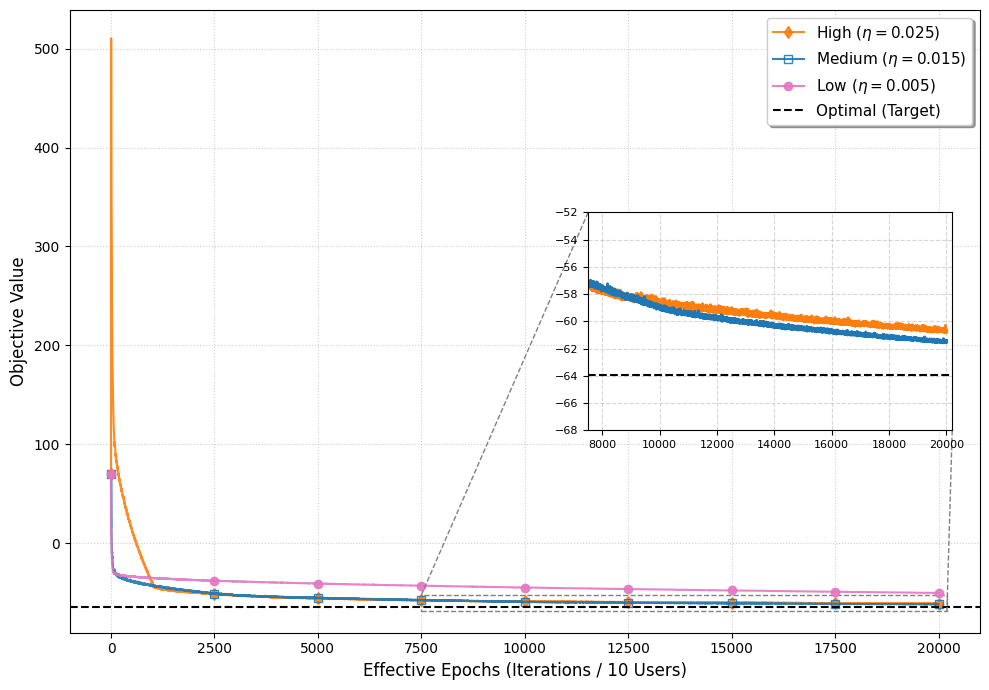

In [29]:
import matplotlib.pyplot as plt
import pickle
import os
import numpy as np
# --- IMPORT THƯ VIỆN VẼ KHUNG ZOOM ---
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# ==============================================================================
# CẤU HÌNH DỮ LIỆU
# ==============================================================================
BASE_DIR = "/content/drive/MyDrive/EV_charging_project/experiment_results/Fig4_21"
EPOCH_LIMIT = 20000

experiments = [
    {
        "label": "High", "eta": 0.025, "filename": "lr_high.pkl", "subdir": "12",
        "color": "#ff7f0e", "marker": "d", "fillstyle": "full"
    },
    {
        "label": "Medium", "eta": 0.015, "filename": "lr_medium.pkl", "subdir": "",
        "color": "#1f77b4", "marker": "s", "fillstyle": "none"
    },
    {
        "label": "Low", "eta": 0.005, "filename": "lr_low.pkl", "subdir": "",
        "color": "#e377c2", "marker": "o", "fillstyle": "full"
    }
]

# ==============================================================================
# CẤU HÌNH KHUNG ZOOM (INSET SETTINGS)
# ==============================================================================
# Dựa trên hình ảnh Fig 4:
# - Optimal khoảng -64
# - Các đường nằm trong khoảng -60 đến -65 ở cuối
# -> Chọn Y từ -68 đến -50 để bao trọn cả đường màu hồng (Low)
# ==============================================================================
ZOOM_X_MIN = 7500
ZOOM_X_MAX = 20200
ZOOM_Y_MIN = -68   # Thấp hơn optimal một chút
ZOOM_Y_MAX = -52   # Cao hơn đường Low (màu hồng) một chút để thoáng

# ==============================================================================
# VẼ BIỂU ĐỒ
# ==============================================================================
# Dùng subplots để quản lý trục chính (ax_main) và trục phụ (ax_inset)
fig, ax_main = plt.subplots(figsize=(10, 7))

# Tạo trục phụ (Inset Axes)
# loc='center right': Đặt ở giữa bên phải (vùng trống trong đồ thị này)
ax_inset = inset_axes(ax_main, width="40%", height="35%", loc='center right', borderpad=2)

global_optimal_val = None
users_count_for_label = 10

print(f"--- Loading & Plotting Data (Limit: {EPOCH_LIMIT} Epochs) ---")

for exp in experiments:
    # 1. Load dữ liệu
    if exp["subdir"]:
        file_path = os.path.join(BASE_DIR, exp["subdir"], exp["filename"])
    else:
        file_path = os.path.join(BASE_DIR, exp["filename"])

    if not os.path.exists(file_path):
        continue

    with open(file_path, 'rb') as f:
        data = pickle.load(f)

    hist = np.array(data["obj_hist"])
    params = data.get("params", {})
    log_freq = params.get("log_freq", 10)

    if data.get("optimal_X") is not None:
        n_users = data["optimal_X"].shape[0]
        users_count_for_label = n_users
    else:
        n_users = 10

    if global_optimal_val is None and data.get("optimal_val") is not None:
        global_optimal_val = data["optimal_val"]

    # 2. Xử lý trục thời gian
    steps = np.arange(len(hist)) * log_freq
    epochs = steps / n_users

    mask = epochs <= EPOCH_LIMIT
    epochs_view = epochs[mask]
    hist_view = hist[mask]

    label_str = fr'{exp["label"]} ($\eta={exp["eta"]}$)'

    # --- VẼ TRÊN TRỤC CHÍNH (CÓ MARKER) ---
    ax_main.plot(epochs_view, hist_view,
             color=exp["color"],
             linestyle='-',
             linewidth=1.5,
             marker=exp["marker"],
             markevery=2500,
             markersize=6,
             fillstyle=exp.get("fillstyle", "full"),
             alpha=0.9,
             label=label_str)

    # --- VẼ TRÊN TRỤC ZOOM (KHÔNG MARKER HOẶC ÍT MARKER) ---
    # Trong khung nhỏ ta vẽ nét liền (linewidth lớn hơn chút) để dễ nhìn xu hướng
    ax_inset.plot(epochs_view, hist_view,
                 color=exp["color"],
                 linestyle='-',
                 linewidth=2.0,
                 alpha=1.0)

    print(f"   ✅ Đã vẽ: {exp['label']} (Final: {hist_view[-1]:.2f})")

# ==============================================================================
# VẼ ĐƯỜNG OPTIMAL (TRÊN CẢ 2 TRỤC)
# ==============================================================================
if global_optimal_val is not None:
    # Trục chính
    ax_main.axhline(y=global_optimal_val, color='black', linestyle='--', linewidth=1.5, label='Optimal (Target)')
    # Trục zoom
    ax_inset.axhline(y=global_optimal_val, color='black', linestyle='--', linewidth=1.5)

# ==============================================================================
# TRANG TRÍ & HOÀN THIỆN
# ==============================================================================
ax_main.set_xlabel(f'Effective Epochs (Iterations / {users_count_for_label} Users)', fontsize=12)
ax_main.set_ylabel('Objective Value', fontsize=12)
ax_main.grid(True, linestyle=':', alpha=0.6)
ax_main.legend(loc='upper right', frameon=True, shadow=True, fontsize=11)

# --- CẤU HÌNH KHUNG ZOOM ---
ax_inset.set_xlim(ZOOM_X_MIN, ZOOM_X_MAX)
ax_inset.set_ylim(ZOOM_Y_MIN, ZOOM_Y_MAX)
ax_inset.tick_params(axis='both', which='major', labelsize=8) # Chữ số nhỏ đi
ax_inset.grid(True, linestyle='--', alpha=0.5)

# Vẽ đường nối
mark_inset(ax_main, ax_inset, loc1=2, loc2=4, fc="none", ec="0.5", ls='--')

plt.tight_layout()
plt.show()

--- Loading & Plotting Data (Limit: 20000 Epochs) ---
   ✅ Đã vẽ: High (Final: -60.75)
   ✅ Đã vẽ: Moderate-High (Final: -62.33)
   ✅ Đã vẽ: Medium (Final: -61.40)
   ✅ Đã vẽ: Moderate-Low (Final: -58.52)
   ✅ Đã vẽ: Low (Final: -50.00)


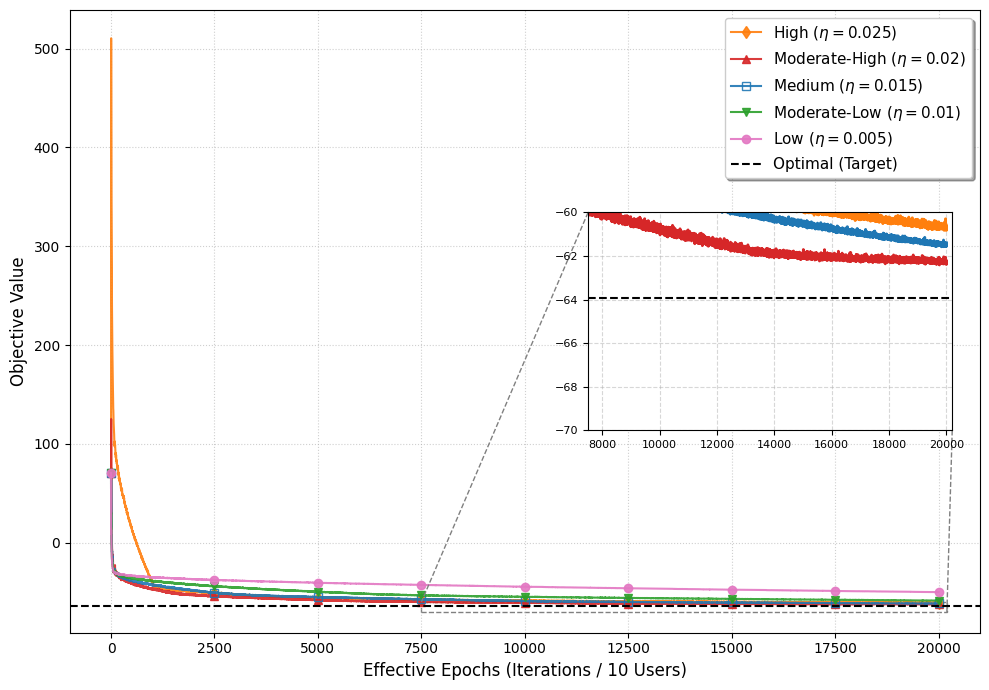

In [30]:
import matplotlib.pyplot as plt
import pickle
import os
import numpy as np
# --- IMPORT THƯ VIỆN VẼ KHUNG ZOOM ---
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# ==============================================================================
# CẤU HÌNH DỮ LIỆU
# ==============================================================================
BASE_DIR = "/content/drive/MyDrive/EV_charging_project/experiment_results/Fig4_21"
EPOCH_LIMIT = 20000

# Đã thêm Moderate-High (0.02) và Moderate-Low (0.01), sắp xếp theo thứ tự eta giảm dần
experiments = [
    {
        "label": "High", "eta": 0.025, "filename": "lr_high.pkl", "subdir": "12",
        "color": "#ff7f0e", "marker": "d", "fillstyle": "full"
    },
    {
        "label": "Moderate-High", "eta": 0.02, "filename": "lr_moderate_high.pkl", "subdir": "",
        "color": "#d62728", "marker": "^", "fillstyle": "full"
    },
    {
        "label": "Medium", "eta": 0.015, "filename": "lr_medium.pkl", "subdir": "",
        "color": "#1f77b4", "marker": "s", "fillstyle": "none"
    },
    {
        "label": "Moderate-Low", "eta": 0.01, "filename": "lr_moderate_low.pkl", "subdir": "",
        "color": "#2ca02c", "marker": "v", "fillstyle": "full"
    },
    {
        "label": "Low", "eta": 0.005, "filename": "lr_low.pkl", "subdir": "",
        "color": "#e377c2", "marker": "o", "fillstyle": "full"
    }
]

# ==============================================================================
# CẤU HÌNH KHUNG ZOOM (INSET SETTINGS)
# ==============================================================================
ZOOM_X_MIN = 7500
ZOOM_X_MAX = 20200
ZOOM_Y_MIN = -70   # Thấp hơn optimal một chút
ZOOM_Y_MAX = -60   # Cao hơn đường Low (màu hồng) một chút để thoáng

# ==============================================================================
# VẼ BIỂU ĐỒ
# ==============================================================================
# Dùng subplots để quản lý trục chính (ax_main) và trục phụ (ax_inset)
fig, ax_main = plt.subplots(figsize=(10, 7))

# Tạo trục phụ (Inset Axes)
ax_inset = inset_axes(ax_main, width="40%", height="35%", loc='center right', borderpad=2)

global_optimal_val = None
users_count_for_label = 10

print(f"--- Loading & Plotting Data (Limit: {EPOCH_LIMIT} Epochs) ---")

for exp in experiments:
    # 1. Load dữ liệu
    if exp["subdir"]:
        file_path = os.path.join(BASE_DIR, exp["subdir"], exp["filename"])
    else:
        file_path = os.path.join(BASE_DIR, exp["filename"])

    if not os.path.exists(file_path):
        print(f"❌ Không tìm thấy file: {file_path}")
        continue

    with open(file_path, 'rb') as f:
        data = pickle.load(f)

    hist = np.array(data["obj_hist"])
    params = data.get("params", {})
    log_freq = params.get("log_freq", 10)

    if data.get("optimal_X") is not None:
        n_users = data["optimal_X"].shape[0]
        users_count_for_label = n_users
    else:
        n_users = 10

    if global_optimal_val is None and data.get("optimal_val") is not None:
        global_optimal_val = data["optimal_val"]

    # 2. Xử lý trục thời gian
    steps = np.arange(len(hist)) * log_freq
    epochs = steps / n_users

    mask = epochs <= EPOCH_LIMIT
    epochs_view = epochs[mask]
    hist_view = hist[mask]

    label_str = fr'{exp["label"]} ($\eta={exp["eta"]}$)'

    # --- VẼ TRÊN TRỤC CHÍNH (CÓ MARKER) ---
    ax_main.plot(epochs_view, hist_view,
             color=exp["color"],
             linestyle='-',
             linewidth=1.5,
             marker=exp["marker"],
             markevery=2500,
             markersize=6,
             fillstyle=exp.get("fillstyle", "full"),
             alpha=0.9,
             label=label_str)

    # --- VẼ TRÊN TRỤC ZOOM (KHÔNG MARKER HOẶC ÍT MARKER) ---
    ax_inset.plot(epochs_view, hist_view,
                 color=exp["color"],
                 linestyle='-',
                 linewidth=2.0,
                 alpha=1.0)

    print(f"   ✅ Đã vẽ: {exp['label']} (Final: {hist_view[-1]:.2f})")

# ==============================================================================
# VẼ ĐƯỜNG OPTIMAL (TRÊN CẢ 2 TRỤC)
# ==============================================================================
if global_optimal_val is not None:
    # Trục chính
    ax_main.axhline(y=global_optimal_val, color='black', linestyle='--', linewidth=1.5, label='Optimal (Target)')
    # Trục zoom
    ax_inset.axhline(y=global_optimal_val, color='black', linestyle='--', linewidth=1.5)

# ==============================================================================
# TRANG TRÍ & HOÀN THIỆN
# ==============================================================================
ax_main.set_xlabel(f'Effective Epochs (Iterations / {users_count_for_label} Users)', fontsize=12)
ax_main.set_ylabel('Objective Value', fontsize=12)
ax_main.grid(True, linestyle=':', alpha=0.6)
ax_main.legend(loc='upper right', frameon=True, shadow=True, fontsize=11)

# --- CẤU HÌNH KHUNG ZOOM ---
ax_inset.set_xlim(ZOOM_X_MIN, ZOOM_X_MAX)
ax_inset.set_ylim(ZOOM_Y_MIN, ZOOM_Y_MAX)
ax_inset.tick_params(axis='both', which='major', labelsize=8)
ax_inset.grid(True, linestyle='--', alpha=0.5)

# Vẽ đường nối
mark_inset(ax_main, ax_inset, loc1=2, loc2=4, fc="none", ec="0.5", ls='--')

plt.tight_layout()
plt.show()

--- Loading & Plotting Data (Limit: 20000 Epochs) ---
   ✅ Đã vẽ: High (Final: -60.75)
   ✅ Đã vẽ: Moderate-High (Final: -62.33)
   ✅ Đã vẽ: Medium (Final: -61.40)
   ✅ Đã vẽ: Moderate-Low (Final: -58.52)
   ✅ Đã vẽ: Low (Final: -50.00)


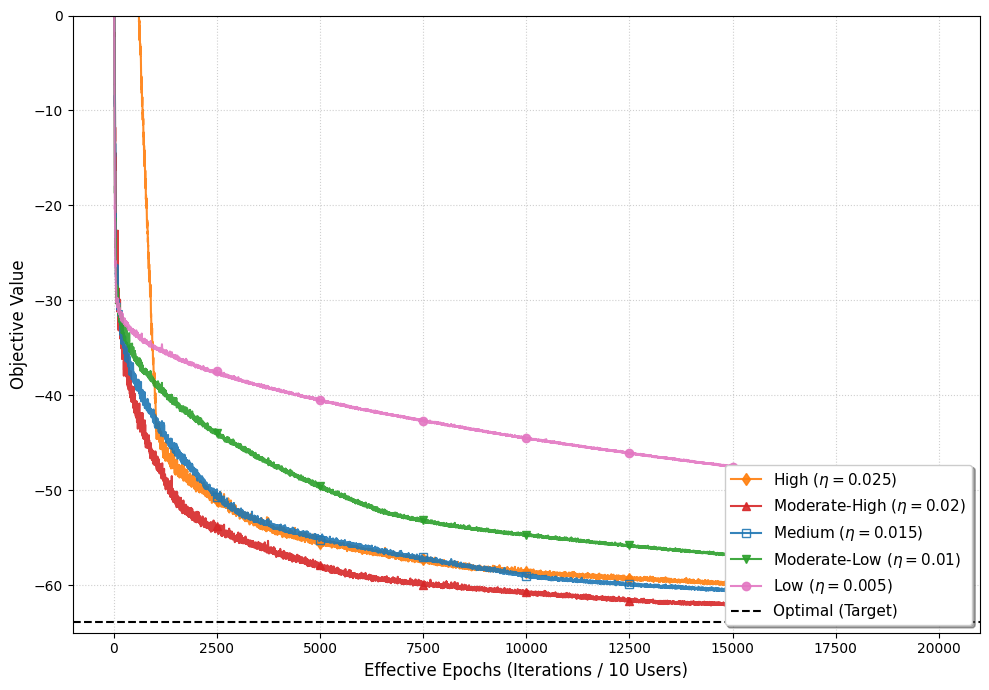

In [31]:
import matplotlib.pyplot as plt
import pickle
import os
import numpy as np

# ==============================================================================
# CẤU HÌNH DỮ LIỆU
# ==============================================================================
BASE_DIR = "/content/drive/MyDrive/EV_charging_project/experiment_results/Fig4_21"
EPOCH_LIMIT = 20000

# Đã thêm Moderate-High (0.02) và Moderate-Low (0.01), sắp xếp theo thứ tự eta giảm dần
experiments = [
    {
        "label": "High", "eta": 0.025, "filename": "lr_high.pkl", "subdir": "12",
        "color": "#ff7f0e", "marker": "d", "fillstyle": "full"
    },
    {
        "label": "Moderate-High", "eta": 0.02, "filename": "lr_moderate_high.pkl", "subdir": "",
        "color": "#d62728", "marker": "^", "fillstyle": "full"
    },
    {
        "label": "Medium", "eta": 0.015, "filename": "lr_medium.pkl", "subdir": "",
        "color": "#1f77b4", "marker": "s", "fillstyle": "none"
    },
    {
        "label": "Moderate-Low", "eta": 0.01, "filename": "lr_moderate_low.pkl", "subdir": "",
        "color": "#2ca02c", "marker": "v", "fillstyle": "full"
    },
    {
        "label": "Low", "eta": 0.005, "filename": "lr_low.pkl", "subdir": "",
        "color": "#e377c2", "marker": "o", "fillstyle": "full"
    }
]

# ==============================================================================
# VẼ BIỂU ĐỒ
# ==============================================================================
fig, ax_main = plt.subplots(figsize=(10, 7))

global_optimal_val = None
users_count_for_label = 10

print(f"--- Loading & Plotting Data (Limit: {EPOCH_LIMIT} Epochs) ---")

for exp in experiments:
    # 1. Load dữ liệu
    if exp["subdir"]:
        file_path = os.path.join(BASE_DIR, exp["subdir"], exp["filename"])
    else:
        file_path = os.path.join(BASE_DIR, exp["filename"])

    if not os.path.exists(file_path):
        print(f"❌ Không tìm thấy file: {file_path}")
        continue

    with open(file_path, 'rb') as f:
        data = pickle.load(f)

    hist = np.array(data["obj_hist"])
    params = data.get("params", {})
    log_freq = params.get("log_freq", 10)

    if data.get("optimal_X") is not None:
        n_users = data["optimal_X"].shape[0]
        users_count_for_label = n_users
    else:
        n_users = 10

    if global_optimal_val is None and data.get("optimal_val") is not None:
        global_optimal_val = data["optimal_val"]

    # 2. Xử lý trục thời gian
    steps = np.arange(len(hist)) * log_freq
    epochs = steps / n_users

    mask = epochs <= EPOCH_LIMIT
    epochs_view = epochs[mask]
    hist_view = hist[mask]

    label_str = fr'{exp["label"]} ($\eta={exp["eta"]}$)'

    # --- VẼ TRÊN TRỤC CHÍNH (CÓ MARKER) ---
    ax_main.plot(epochs_view, hist_view,
             color=exp["color"],
             linestyle='-',
             linewidth=1.5,
             marker=exp["marker"],
             markevery=2500,
             markersize=6,
             fillstyle=exp.get("fillstyle", "full"),
             alpha=0.9,
             label=label_str)

    print(f"   ✅ Đã vẽ: {exp['label']} (Final: {hist_view[-1]:.2f})")

# ==============================================================================
# VẼ ĐƯỜNG OPTIMAL
# ==============================================================================
if global_optimal_val is not None:
    ax_main.axhline(y=global_optimal_val, color='black', linestyle='--', linewidth=1.5, label='Optimal (Target)')

# ==============================================================================
# TRANG TRÍ & HOÀN THIỆN
# ==============================================================================
ax_main.set_xlabel(f'Effective Epochs (Iterations / {users_count_for_label} Users)', fontsize=12)
ax_main.set_ylabel('Objective Value', fontsize=12)

# --- THIẾT LẬP GIỚI HẠN TRỤC Y ---
ax_main.set_ylim(-65, 0)

ax_main.grid(True, linestyle=':', alpha=0.6)
ax_main.legend(loc='lower right', frameon=True, shadow=True, fontsize=11)

plt.tight_layout()
plt.show()

--- Loading & Plotting Data for Moderate-High (Limit: 20000 Epochs) ---
   ✅ Đã vẽ: Moderate-High (Final: -62.33)


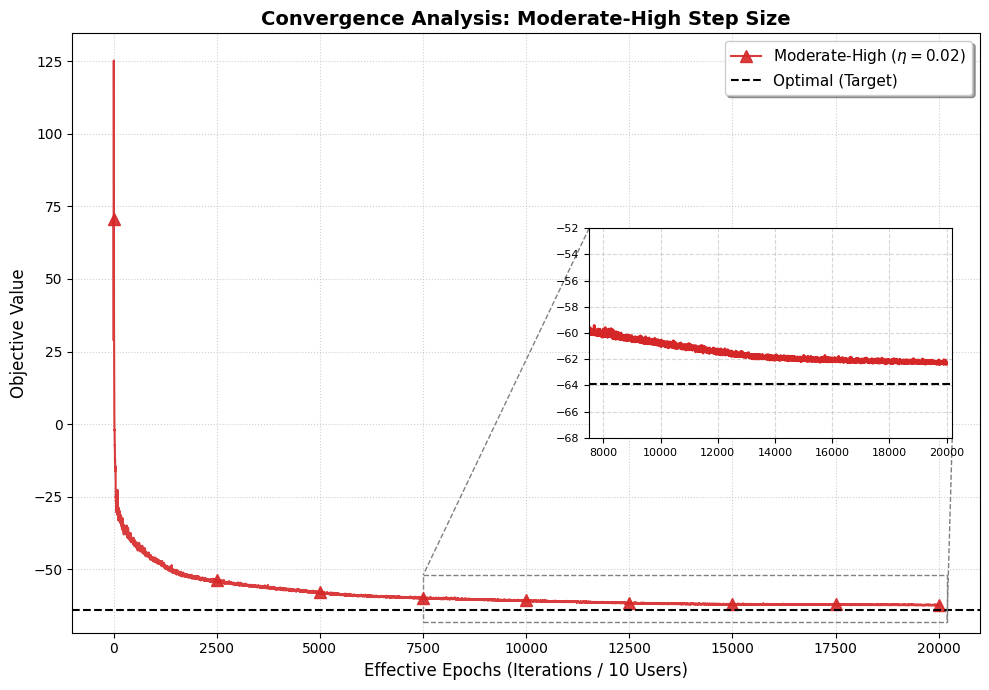

In [32]:
import matplotlib.pyplot as plt
import pickle
import os
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# ==============================================================================
# CẤU HÌNH DỮ LIỆU
# ==============================================================================
BASE_DIR = "/content/drive/MyDrive/EV_charging_project/experiment_results/Fig4_21"
EPOCH_LIMIT = 20000

# Chỉ giữ lại cấu hình cho đường Moderate-High
experiments = [
    {
        "label": "Moderate-High", "eta": 0.02, "filename": "lr_moderate_high.pkl", "subdir": "",
        "color": "#d62728", "marker": "^", "fillstyle": "full"
    }
]

# ==============================================================================
# CẤU HÌNH KHUNG ZOOM (INSET SETTINGS)
# ==============================================================================
ZOOM_X_MIN = 7500
ZOOM_X_MAX = 20200
ZOOM_Y_MIN = -68
ZOOM_Y_MAX = -52

# ==============================================================================
# VẼ BIỂU ĐỒ
# ==============================================================================
fig, ax_main = plt.subplots(figsize=(10, 7))

# Tạo trục phụ (Inset Axes)
ax_inset = inset_axes(ax_main, width="40%", height="35%", loc='center right', borderpad=2)

global_optimal_val = None
users_count_for_label = 10

print(f"--- Loading & Plotting Data for Moderate-High (Limit: {EPOCH_LIMIT} Epochs) ---")

for exp in experiments:
    # 1. Load dữ liệu
    if exp["subdir"]:
        file_path = os.path.join(BASE_DIR, exp["subdir"], exp["filename"])
    else:
        file_path = os.path.join(BASE_DIR, exp["filename"])

    if not os.path.exists(file_path):
        print(f"❌ Không tìm thấy file: {file_path}")
        continue

    with open(file_path, 'rb') as f:
        data = pickle.load(f)

    hist = np.array(data["obj_hist"])
    params = data.get("params", {})
    log_freq = params.get("log_freq", 10)

    if data.get("optimal_X") is not None:
        n_users = data["optimal_X"].shape[0]
        users_count_for_label = n_users
    else:
        n_users = 10

    if global_optimal_val is None and data.get("optimal_val") is not None:
        global_optimal_val = data["optimal_val"]

    # 2. Xử lý trục thời gian
    steps = np.arange(len(hist)) * log_freq
    epochs = steps / n_users

    mask = epochs <= EPOCH_LIMIT
    epochs_view = epochs[mask]
    hist_view = hist[mask]

    label_str = fr'{exp["label"]} ($\eta={exp["eta"]}$)'

    # --- VẼ TRÊN TRỤC CHÍNH ---
    ax_main.plot(epochs_view, hist_view,
             color=exp["color"],
             linestyle='-',
             linewidth=1.5,
             marker=exp["marker"],
             markevery=2500,
             markersize=8, # Tăng marker size lên một chút cho rõ vì chỉ có 1 đường
             fillstyle=exp.get("fillstyle", "full"),
             alpha=0.9,
             label=label_str)

    # --- VẼ TRÊN TRỤC ZOOM ---
    ax_inset.plot(epochs_view, hist_view,
                 color=exp["color"],
                 linestyle='-',
                 linewidth=2.0,
                 alpha=1.0)

    print(f"   ✅ Đã vẽ: {exp['label']} (Final: {hist_view[-1]:.2f})")

# ==============================================================================
# VẼ ĐƯỜNG OPTIMAL (TRÊN CẢ 2 TRỤC)
# ==============================================================================
if global_optimal_val is not None:
    ax_main.axhline(y=global_optimal_val, color='black', linestyle='--', linewidth=1.5, label='Optimal (Target)')
    ax_inset.axhline(y=global_optimal_val, color='black', linestyle='--', linewidth=1.5)

# ==============================================================================
# TRANG TRÍ & HOÀN THIỆN
# ==============================================================================
ax_main.set_xlabel(f'Effective Epochs (Iterations / {users_count_for_label} Users)', fontsize=12)
ax_main.set_ylabel('Objective Value', fontsize=12)
ax_main.set_title("Convergence Analysis: Moderate-High Step Size", fontsize=14, fontweight='bold')
ax_main.grid(True, linestyle=':', alpha=0.6)
ax_main.legend(loc='upper right', frameon=True, shadow=True, fontsize=11)

# --- CẤU HÌNH KHUNG ZOOM ---
ax_inset.set_xlim(ZOOM_X_MIN, ZOOM_X_MAX)
ax_inset.set_ylim(ZOOM_Y_MIN, ZOOM_Y_MAX)
ax_inset.tick_params(axis='both', which='major', labelsize=8)
ax_inset.grid(True, linestyle='--', alpha=0.5)

# Vẽ đường nối
mark_inset(ax_main, ax_inset, loc1=2, loc2=4, fc="none", ec="0.5", ls='--')

plt.tight_layout()
plt.show()

## 1b

--- Processing Convergence Plot (Window Size: 50) ---
✅ [PLOTTING] Linear...
✅ [PLOTTING] Cobb-Douglas...
⚠️  [MISSING] Không tìm thấy file: /content/drive/MyDrive/EV_charging_project/experiment_results/Fig1_20/12/experiment_data_leontief.pkl
✅ [PLOTTING] CES_8...


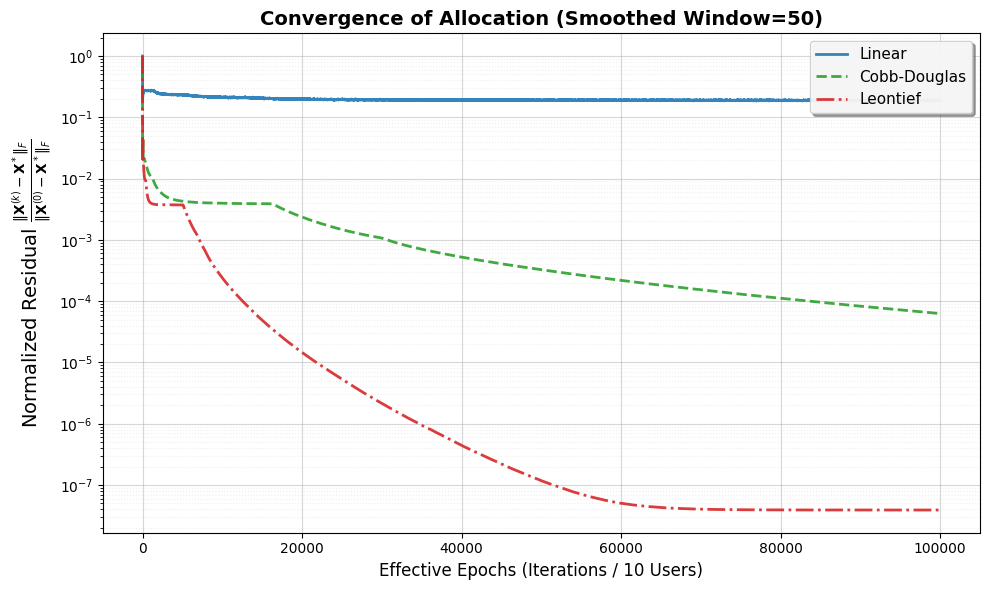

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
import os

# ==============================================================================
# 1. CẤU HÌNH & KHỞI TẠO
# ==============================================================================
SAVE_DIR = "/content/drive/MyDrive/EV_charging_project/experiment_results/Fig1_20/12"
UTILITY_TYPES = ["Linear", "Cobb-Douglas", "Leontief", "CES_8"]
WINDOW_SIZE = 50  # Tăng lên 50 để đường vẽ mượt hơn (SGD thường rất rung)

# Cấu hình màu và kiểu đường (THÊM CES_8 VÀO ĐÂY)
STYLES = {
    "Linear":       {"color": "#1f77b4", "linestyle": "-",  "label": "Linear"},        # Xanh dương
    "Cobb-Douglas": {"color": "#2ca02c", "linestyle": "--", "label": "Cobb-Douglas"},  # Xanh lá
    "CES_8":     {"color": "#d62728", "linestyle": "-.", "label": "Leontief"}
}

plt.figure(figsize=(10, 6))
captured_n_users = 10

# ==============================================================================
# 2. VÒNG LẶP XỬ LÝ & VẼ
# ==============================================================================
print(f"--- Processing Convergence Plot (Window Size: {WINDOW_SIZE}) ---")

for u_type in UTILITY_TYPES:
    # 1. Load file
    safe_name = u_type.lower().replace("-", "_")
    file_path = os.path.join(SAVE_DIR, f"experiment_data_{safe_name}.pkl")

    # --- SỬA LỖI 1: Lấy style tương ứng ---
    style = STYLES.get(u_type, {"color": "black", "linestyle": "-", "label": u_type})

    if not os.path.exists(file_path):
        print(f"⚠️  [MISSING] Không tìm thấy file: {file_path}")
        continue

    try:
        with open(file_path, "rb") as f:
            data = pickle.load(f)
    except Exception as e:
        print(f"❌ [ERROR] Lỗi đọc file {u_type}: {e}")
        continue

    # 2. Lấy dữ liệu
    X_star = data.get("optimal_X")
    alloc_hist = data.get("alloc_hist")
    params = data.get("params", {})
    log_freq = params.get("log_freq", 10)


    # 3. Kiểm tra dữ liệu
    if X_star is None:
        print(f"⏭️  [SKIP] {u_type}: Không có nghiệm tối ưu trung tâm (X*) để so sánh.")
        # Lưu ý: CES_8 thường sẽ rơi vào case này nếu Solver tập trung ko chạy được
        continue

    if alloc_hist is None or len(alloc_hist) == 0:
        print(f"⏭️  [SKIP] {u_type}: Không có lịch sử Allocation.")
        continue

    print(f"✅ [PLOTTING] {u_type}...")

    # Cập nhật số user để chia Epoch cho đúng
    n_users_current = X_star.shape[0]
    captured_n_users = n_users_current

    # --- TÍNH TOÁN NORMALIZED RESIDUALS ---
    # Residual = ||X_k - X*||_F / ||X_0 - X*||_F

    # Mẫu số: Sai số ban đầu
    X_0 = alloc_hist[0]
    denom = np.linalg.norm(X_0 - X_star, 'fro')

    residuals = []
    for X_k in alloc_hist:
        num = np.linalg.norm(X_k - X_star, 'fro')
        residuals.append(num / denom)

    residuals = np.array(residuals)

    # --- XỬ LÝ SMOOTHING (SMA) ---
    if len(residuals) >= WINDOW_SIZE:
        residuals_smoothed = np.convolve(
            residuals,
            np.ones(WINDOW_SIZE)/WINDOW_SIZE,
            mode='valid'
        )
        # Tạo trục X (Epochs) tương ứng
        # Do mode='valid', mảng ngắn đi (WINDOW_SIZE - 1) phần tử
        raw_iterations = np.arange(len(residuals)) * log_freq
    all_epochs = raw_iterations / n_users_current

    if len(residuals) >= WINDOW_SIZE and WINDOW_SIZE > 1:
        # 1. Tính toán phần đã làm mượt (sẽ ngắn hơn dữ liệu gốc)
        residuals_smoothed_valid = np.convolve(
            residuals,
            np.ones(WINDOW_SIZE)/WINDOW_SIZE,
            mode='valid'
        )

        # 2. Kỹ thuật ghép nối:
        # Để biểu đồ bắt đầu chính xác từ 1 (dữ liệu thô tại t=0),
        # ta dùng dữ liệu thô cho đoạn đầu, và dữ liệu smooth cho đoạn sau.

        # Lấy (WINDOW_SIZE - 1) điểm dữ liệu thô đầu tiên
        head_raw = residuals[:WINDOW_SIZE-1]

        # Ghép với phần đã smooth
        # Tổng chiều dài sẽ bằng đúng chiều dài dữ liệu gốc
        data_to_plot = np.concatenate((head_raw, residuals_smoothed_valid))

        # Sử dụng trục X đầy đủ
        epochs_to_plot = all_epochs

    else:
        # Fallback nếu dữ liệu quá ngắn hoặc window=1
        epochs_to_plot = all_epochs
        data_to_plot = residuals

    # --- VẼ (Đã cập nhật biến) ---
    # Thêm marker tại điểm đầu tiên để nhấn mạnh nó bắt đầu từ 1
    plt.semilogy(epochs_to_plot, data_to_plot,
                 color=style["color"],
                 linestyle=style["linestyle"],
                 linewidth=2.0,
                 alpha=0.9,
                 label=style["label"])

# ==============================================================================
# 3. TRANG TRÍ & HOÀN THIỆN CHART
# ==============================================================================
plt.xlabel(f'Effective Epochs (Iterations / {captured_n_users} Users)', fontsize=12)
plt.ylabel(r'Normalized Residual $\frac{\|\mathbf{X}^{(k)} - \mathbf{X}^*\|_F}{\|\mathbf{X}^{(0)} - \mathbf{X}^*\|_F}$', fontsize=14)
plt.title(f'Convergence of Allocation (Smoothed Window={WINDOW_SIZE})', fontsize=14, fontweight='bold')

plt.grid(True, which="major", linestyle='-', alpha=0.5)
plt.grid(True, which="minor", linestyle=':', alpha=0.2)
plt.legend(fontsize=11, loc='upper right', framealpha=0.9, shadow=True)

plt.tight_layout()
plt.show()

In [34]:
obj_hist[0]

np.float64(70.60183689840474)